### Librerías a utilizar
---

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from imblearn.over_sampling import SMOTE
import os

### Importación de datos
---

In [4]:
df = pd.read_csv('../data/raw/synthetic_coffee_health_10000.csv')
df.head()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


### Dropeo de Columnas
---

In [5]:
# Quitar columna Health_Issues
df = df.drop(columns=['Health_Issues', 'Caffeine_mg'])
df.head()

,ID,Age,Gender,Country,Coffee_Intake,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,7.5,Good,24.9,78,Low,14.5,Other,0,0
1,2,33,Male,Germany,1.0,6.2,Good,20.0,67,Low,11.0,Service,0,0
2,3,42,Male,Brazil,5.3,5.9,Fair,22.7,59,Medium,11.2,Office,0,0
3,4,53,Male,Germany,2.6,7.3,Good,24.7,71,Low,6.6,Other,0,0
4,5,32,Female,Spain,3.1,5.3,Fair,24.1,76,Medium,8.5,Student,0,1



Al realizar el EDA, se notó que la cantidad de nulos en la columna Health_Issues era muy grande, por lo que se tomó la decision de eliminarla completamente. Mientras que Caffeine?mg tenía una correlacion demasiado alta con Coffee_Intake, ya que practicamente son lo mismo pero 1 en tazas y el otro en Mg. 

In [6]:
# Filtrar filas donde Gender no sea 'Others'
df = df[df["Gender"] != "Other"]

# Verificar
print(df["Gender"].value_counts())


Gender
Female    5001
Male      4773
Name: count, dtype: int64


Se tomó esta decisión ya que la cantidad de datos en other era el 2.26% del total, y al ser tan pocos datos, se decidió eliminarlos para evitar que afecten.

### Codificación Variables Categóricas
---

In [7]:
pais_a_continente = {
    "Canada": "America",
    "USA": "America",
    "Mexico": "America",
    "Brazil": "America",
    "Norway": "Europe",
    "Sweden": "Europe",
    "UK": "Europe",
    "Finland": "Europe",
    "Italy": "Europe",
    "Belgium": "Europe",
    "Germany": "Europe",
    "France": "Europe",
    "Switzerland": "Europe",
    "Netherlands": "Europe",
    "Spain": "Europe",
    "India": "Asia",
    "China": "Asia",
    "South Korea": "Asia",
    "Japan": "Asia",
    "Australia": "Oceania"
}
df["Continent"] = df["Country"].map(pais_a_continente)

In [8]:
# Map de variables categoricas
df['Sleep_Quality'] = df['Sleep_Quality'].map({'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3})
df['Stress_Level'] = df['Stress_Level'].map({'Low': 0, 'Medium': 1, 'High': 2})
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df = pd.get_dummies(df, columns=['Occupation'], drop_first=True)
df = pd.get_dummies(df, columns=["Continent"])

In [9]:
df = df.drop(columns=["Country"])

In [10]:
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

In [11]:
df.head()

,ID,Age,Gender,Coffee_Intake,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Smoking,Alcohol_Consumption,Occupation_Office,Occupation_Other,Occupation_Service,Occupation_Student,Continent_America,Continent_Asia,Continent_Europe,Continent_Oceania
0,1,40,0,3.5,7.5,2,24.9,78,0,14.5,0,0,0,1,0,0,0,0,1,0
1,2,33,0,1.0,6.2,2,20.0,67,0,11.0,0,0,0,0,1,0,0,0,1,0
2,3,42,0,5.3,5.9,1,22.7,59,1,11.2,0,0,1,0,0,0,1,0,0,0
3,4,53,0,2.6,7.3,2,24.7,71,0,6.6,0,0,0,1,0,0,0,0,1,0
4,5,32,1,3.1,5.3,1,24.1,76,1,8.5,0,1,0,0,0,1,0,0,1,0


Se decidió agrupar los países en continentes para poder realizar un One Hot Encoding y así no perder esta iformación, de igual manera se codificó los demás datos para poder hacer un Feature Selection más adeltante e incluir la mayor cantidad de columnas en este.

### Feature Selection
---

In [ ]:
from sklearn.feature_selection import mutual_info_classif

In [ ]:
X = df.drop(columns=['Stress_Level'])
y = df['Stress_Level']

# Eliminar variables con alta correlación 
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
print("Eliminando por correlación alta:", to_drop)

X_filtered = X.drop(columns=to_drop, errors='ignore')

mi = mutual_info_classif(X_filtered, y, random_state=42)
mi_series = pd.Series(mi, index=X_filtered.columns)
top_features = mi_series.nlargest(20).index  
print("Top features seleccionadas:", list(top_features))

X_selected = X_filtered[top_features]



Eliminando por correlación alta: ['Sleep_Quality']
Top features seleccionadas: ['Sleep_Hours', 'Coffee_Intake', 'ID', 'Occupation_Other', 'Continent_America', 'Continent_Asia', 'Occupation_Service', 'Heart_Rate', 'Gender', 'Continent_Oceania', 'Age', 'Smoking', 'Physical_Activity_Hours', 'BMI', 'Alcohol_Consumption', 'Occupation_Office', 'Occupation_Student', 'Continent_Europe']


La selección de características se hizo en dos pasos. Primero, se eliminaron las variables que estaban muy relacionadas entre sí (con correlación mayor a 0.9) para evitar repetir información. Luego, se usó el método de información mutua para quedarse con las 20 variables que más influyen en el Stress Level. De esta forma, se conservaron solo las 15 variables más útiles para que los modelos puedan hacer mejores predicciones.

### Balanceo de Variable Objetivo
---

In [14]:
# Stress_Level 
X = df.drop(columns=["Stress_Level"])
y = df["Stress_Level"]

smote = SMOTE(random_state=42)
X_bal_stress, y_bal_stress = smote.fit_resample(X, y)

print("\nStress_Level balanceado:")
print(y_bal_stress.value_counts())


Stress_Level balanceado:
Stress_Level
0    6828
1    6828
2    6828
Name: count, dtype: int64


C:\Users\sarah\AppData\Local\Temp\ipykernel_34700\3408405339.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_bal_stress, palette='viridis')


Text(0.5, 0, 'Stress_Level')

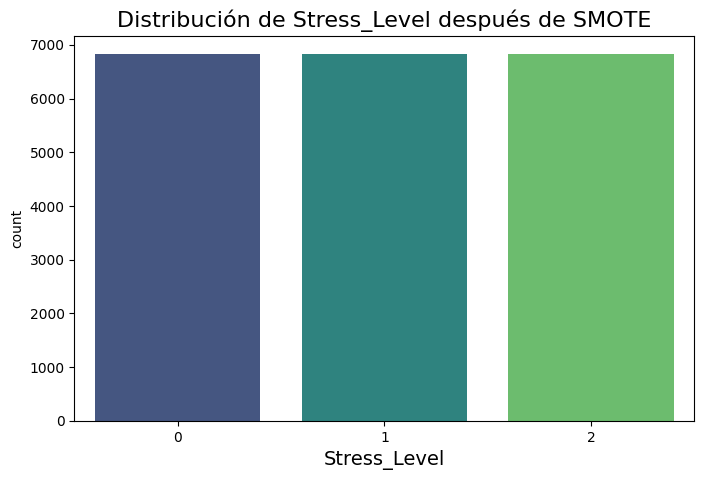

In [15]:
# Grafica datos balanceados
plt.figure(figsize=(8, 5))
sns.countplot(x=y_bal_stress, palette='viridis')
plt.title('Distribución de Stress_Level después de SMOTE', fontsize=16)
plt.xlabel('Stress_Level', fontsize=14)

El balanceo de  Stress_Level se realizó porque sus clases están desigualmente representadas, lo que puede hacer que el modelo prediga mayormente la clase mayoritaria y falle al identificar la minoritaria. Al balancear se garantiza que el modelo aprenda igual sobre todas las clases.

### Guardar en data/processed
---

In [26]:
df.to_csv('../data/processed/dataset_limpio.csv', index=False)

### Conclusiones preliminares
---

***Valores seleccionadas***

Se empezará a trabajar con las variables seleccionadas con el VIF, para de esta manera hacer los primeros pasos para el modelado.

***Métricas para el modelo***

Dado que no hay valores duplicados ni nulos, no será necesario un preprocesamiento adicional, permitiendo entrenar el modelo directamente con los datos seleccionados. Se obtendrán métricas como Accuracy, Precission, Recall & F1-Score.

***Matrices de confusión***

Se generarán matrices de confusión para cada modelo, lo que permitirá evaluar de manera clara cómo se comporta el modelo frente a cada clase, identificando aciertos y errores por categoría y facilitando ajustes futuros.
